**Lab2-DL: B3-heart-disease-classification.ipynb** (BMED365) | Priority: 1 (core)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/B3-heart-disease-classification.ipynb)

# 🎓 Heart Disease Classification with Neural Networks

**A Hands-On Introduction to Medical AI**

Updated: 2025-12-22, A. Lundervold

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Load and explore** a real medical dataset
2. **Prepare data** for machine learning (splitting, scaling)
3. **Build** a simple neural network in PyTorch
4. **Train** the model and monitor its progress
5. **Evaluate** performance using clinical metrics
6. **Interpret** what the model has learned

---

## 🏥 The Clinical Problem

**Can we predict heart disease from patient data?**

Cardiovascular disease is the leading cause of death worldwide. Early detection is crucial for treatment. We'll build an AI model that learns to recognize patterns in patient data that indicate heart disease.

**Our approach:**
- Use 13 clinical measurements (age, blood pressure, ECG results, etc.)
- Train a neural network to classify: **Healthy** vs **Heart Disease**
- Evaluate if the model is good enough for clinical use


---

# Part 1: Setup and Data Loading

---


In [54]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch for neural networks
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn for data processing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')

print("✅ Libraries loaded successfully!")
print(f"PyTorch version: {torch.__version__}")


✅ Libraries loaded successfully!
PyTorch version: 2.6.0


## 📥 Loading the UCI Heart Disease Dataset

The [UCI Heart Disease Dataset](https://archive.ics.uci.edu/ml/datasets/heart+disease) is a classic dataset containing data from 303 patients at the Cleveland Clinic.

**The 13 features:**

| Feature | Description | Type |
|---------|-------------|------|
| age | Patient age | Continuous (years) |
| sex | 0=Female, 1=Male | Binary |
| cp | Chest pain type (0-3) | Categorical |
| trestbps | Resting blood pressure | Continuous (mmHg) |
| chol | Serum cholesterol | Continuous (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl | Binary |
| restecg | Resting ECG results (0-2) | Categorical |
| thalach | Maximum heart rate achieved | Continuous (bpm) |
| exang | Exercise-induced angina | Binary |
| oldpeak | ST depression during exercise | Continuous (mm) |
| slope | Slope of peak exercise ST segment | Categorical |
| ca | Number of major vessels (0-3) | Discrete |
| thal | Thalassemia type | Categorical |

**Target:** 0 = No heart disease, 1-4 = Severity grades (we'll simplify to binary)


In [ ]:
# Download and load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=column_names, na_values='?')

# Remove rows with missing values
df = df.dropna().reset_index(drop=True)

print(f"📊 Dataset shape: {df.shape[0]} patients × {df.shape[1]} columns")
print(f"\n🎯 Target distribution (original):")
print(df['target'].value_counts().sort_index())


📊 Dataset shape: 297 patients × 14 columns

🎯 Target distribution (original):
target
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64


### Converting to Binary Classification

The original dataset has 5 classes (0-4), but for simplicity we'll convert to:
- **0 = Healthy** (no heart disease)
- **1 = Heart Disease** (any severity grade 1-4)

This is also more clinically relevant: *"Does the patient have heart disease or not?"*


In [ ]:
# Convert to binary: 0 = healthy, 1 = any heart disease
df['target_binary'] = (df['target'] > 0).astype(int)

print("🎯 Binary target distribution:")
print(df['target_binary'].value_counts())
print(f"\n   Healthy: {(df['target_binary']==0).sum()} ({100*(df['target_binary']==0).mean():.1f}%)")
print(f"   Heart Disease: {(df['target_binary']==1).sum()} ({100*(df['target_binary']==1).mean():.1f}%)")


🎯 Binary target distribution:
target_binary
0    160
1    137
Name: count, dtype: int64

   Healthy: 160 (53.9%)
   Heart Disease: 137 (46.1%)


---

# Part 2: Exploratory Data Analysis

Before building a model, we should **understand our data**. This helps us:
- Identify patterns that might be useful for prediction
- Spot potential problems (outliers, imbalanced classes)
- Build intuition about what the model should learn

---


In [57]:
# Basic statistics
print("📊 Dataset Summary:")
df.describe().round(1)


📊 Dataset Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_binary
count,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0
mean,54.5,0.7,3.2,131.7,247.4,0.1,1.0,149.6,0.3,1.1,1.6,0.7,4.7,0.9,0.5
std,9.0,0.5,1.0,17.8,52.0,0.4,1.0,22.9,0.5,1.2,0.6,0.9,1.9,1.2,0.5
min,29.0,0.0,1.0,94.0,126.0,0.0,0.0,71.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0
25%,48.0,0.0,3.0,120.0,211.0,0.0,0.0,133.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0
50%,56.0,1.0,3.0,130.0,243.0,0.0,1.0,153.0,0.0,0.8,2.0,0.0,3.0,0.0,0.0
75%,61.0,1.0,4.0,140.0,276.0,0.0,2.0,166.0,1.0,1.6,2.0,1.0,7.0,2.0,1.0
max,77.0,1.0,4.0,200.0,564.0,1.0,2.0,202.0,1.0,6.2,3.0,3.0,7.0,4.0,1.0


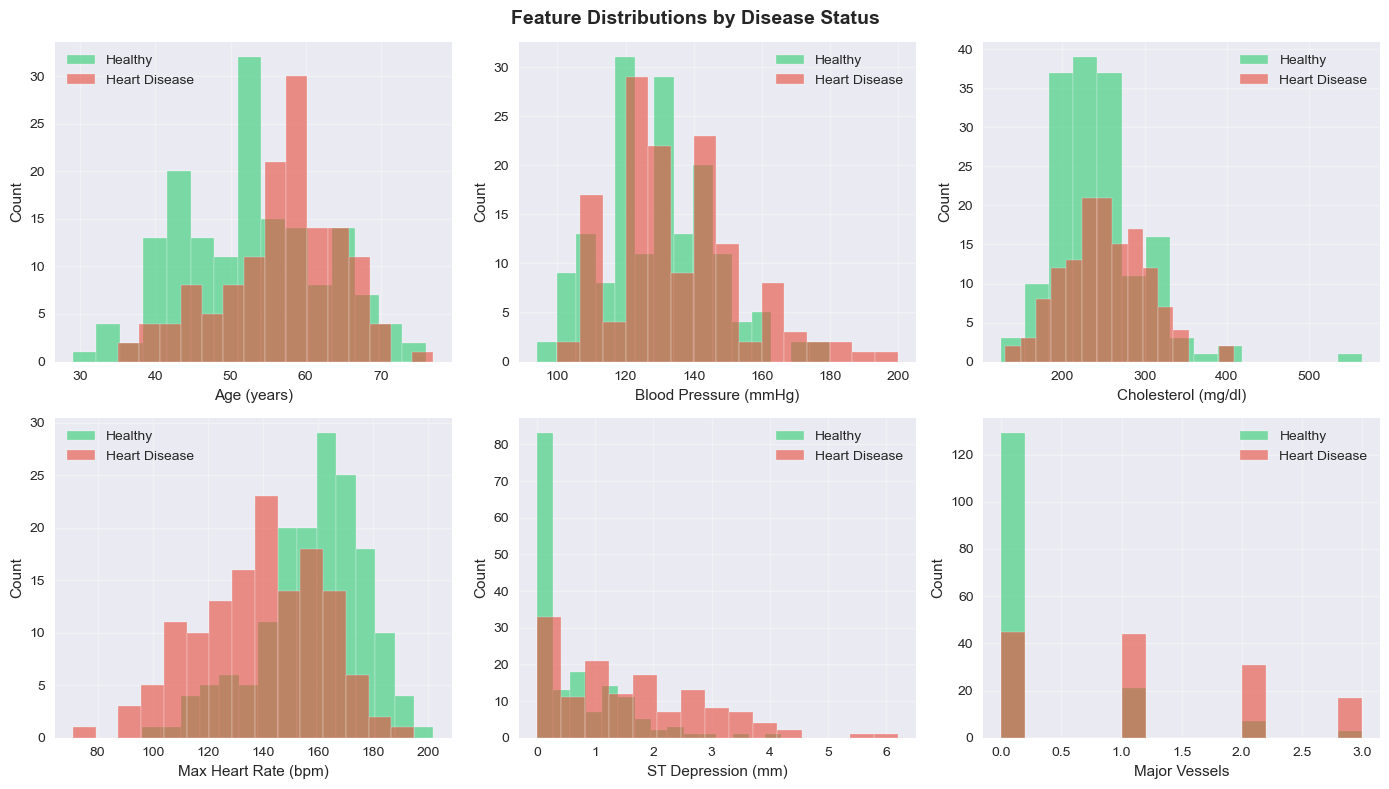

In [58]:
# Visualize key features by disease status
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Features to plot
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
titles = ['Age (years)', 'Blood Pressure (mmHg)', 'Cholesterol (mg/dl)', 
          'Max Heart Rate (bpm)', 'ST Depression (mm)', 'Major Vessels']

for ax, feature, title in zip(axes.flatten(), features, titles):
    for label, color, name in [(0, '#2ecc71', 'Healthy'), (1, '#e74c3c', 'Heart Disease')]:
        data = df[df['target_binary'] == label][feature]
        ax.hist(data, bins=15, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions by Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 🔍 What do we observe?

Looking at the histograms above:
- **Max Heart Rate (thalach)**: Patients with heart disease tend to have *lower* maximum heart rates
- **ST Depression (oldpeak)**: Patients with heart disease show *higher* ST depression values
- **Major Vessels (ca)**: More blocked vessels correlates with heart disease

These patterns make clinical sense and suggest our model should be able to learn useful patterns!


---

## ⚠️ Exercise 1: Correlation Analysis

**Task:** Which feature has the *strongest correlation* with heart disease (target_binary)?

Run the code below, then answer the question.

<details>
<summary>💡 <b>Click here for hint</b></summary>

Look at the last row/column of the correlation matrix (target_binary). The feature with the highest absolute correlation value is most strongly associated with heart disease.

</details>


In [59]:
# Calculate correlations with target
correlations = df.drop('target', axis=1).corr()['target_binary'].sort_values(key=abs, ascending=False)
print("📊 Correlation with Heart Disease (sorted by absolute value):")
print(correlations.round(3))


📊 Correlation with Heart Disease (sorted by absolute value):
target_binary    1.000
thal             0.527
ca               0.463
oldpeak          0.424
thalach         -0.424
exang            0.421
cp               0.409
slope            0.333
sex              0.278
age              0.227
restecg          0.166
trestbps         0.153
chol             0.080
fbs              0.003
Name: target_binary, dtype: float64


<details>
<summary>💡 <b>Click here for the answer</b></summary>

### Answer:

The features with the **strongest correlations** with heart disease are typically:

1. **ca** (number of major vessels): ~0.5 positive correlation
   - *More blocked vessels → higher chance of disease*

2. **thalach** (max heart rate): ~-0.4 negative correlation  
   - *Lower max heart rate → higher chance of disease*

3. **oldpeak** (ST depression): ~0.4 positive correlation
   - *Higher ST depression → higher chance of disease*

4. **exang** (exercise-induced angina): ~0.4 positive correlation
   - *Chest pain during exercise → higher chance of disease*

These make clinical sense! Blocked vessels, reduced exercise capacity, and ECG abnormalities are all known indicators of heart disease.

</details>


---

# Part 3: Data Preparation

Before training, we need to:

1. **Split the data** into training and test sets
2. **Scale the features** so they have similar ranges
3. **Convert to PyTorch tensors** for the neural network

---


In [60]:
# Prepare features and target
feature_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X = df[feature_names].values
y = df['target_binary'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (297, 13)
Target shape: (297,)


### Why Split the Data?

We split into **training** and **test** sets to evaluate how well our model generalizes to new, unseen patients.

- **Training set (80%)**: Used to train the model
- **Test set (20%)**: Held out for final evaluation

⚠️ **Important:** We use `stratify=y` to ensure both sets have the same proportion of healthy/sick patients.


In [61]:
# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Test set: {X_test.shape[0]} patients")
print(f"\nClass distribution in training set:")
print(f"  Healthy: {(y_train==0).sum()}  |  Heart Disease: {(y_train==1).sum()}")


Training set: 237 patients
Test set: 60 patients

Class distribution in training set:
  Healthy: 128  |  Heart Disease: 109


### Why Scale the Features?

Neural networks work better when features are on similar scales. For example:
- Age ranges from ~30 to ~80
- Cholesterol ranges from ~100 to ~500

**StandardScaler** transforms each feature to have:
- Mean = 0
- Standard deviation = 1

⚠️ **Important:** We fit the scaler *only on training data* to prevent data leakage!


In [62]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data only
X_test_scaled = scaler.transform(X_test)        # Apply same transformation to test

print("Before scaling - Age: min={:.1f}, max={:.1f}".format(X_train[:,0].min(), X_train[:,0].max()))
print("After scaling  - Age: min={:.2f}, max={:.2f}".format(X_train_scaled[:,0].min(), X_train_scaled[:,0].max()))


Before scaling - Age: min=34.0, max=77.0
After scaling  - Age: min=-2.30, max=2.47


In [63]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.LongTensor(y_test)

# Create DataLoader for batching
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"✅ Data ready for training!")
print(f"   Input size: {X_train_tensor.shape[1]} features")
print(f"   Output classes: 2 (Healthy, Heart Disease)")


✅ Data ready for training!
   Input size: 13 features
   Output classes: 2 (Healthy, Heart Disease)


---

# Part 4: Building the Neural Network

Now we'll build a simple **feedforward neural network** with:
- An input layer (13 features)
- Two hidden layers (64 and 32 neurons)
- An output layer (2 classes)

---


In [64]:
class HeartDiseaseNN(nn.Module):
    """Simple neural network for heart disease classification"""
    
    def __init__(self, input_size=13, hidden1=64, hidden2=32, output_size=2):
        super(HeartDiseaseNN, self).__init__()
        
        # Define layers
        self.layer1 = nn.Linear(input_size, hidden1)  # Input → Hidden1
        self.layer2 = nn.Linear(hidden1, hidden2)     # Hidden1 → Hidden2
        self.layer3 = nn.Linear(hidden2, output_size) # Hidden2 → Output
        
        # Activation and regularization
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)  # Prevent overfitting
    
    def forward(self, x):
        # Forward pass through the network
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.dropout(x)
        x = self.layer3(x)  # No activation (handled by loss function)
        return x

# Create the model
model = HeartDiseaseNN()
print(model)


HeartDiseaseNN(
  (layer1): Linear(in_features=13, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=2, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


### Understanding the Architecture

```
Input (13 features)
    ↓
Linear(13 → 64) + ReLU + Dropout
    ↓
Linear(64 → 32) + ReLU + Dropout
    ↓
Linear(32 → 2)
    ↓
Output (2 classes: Healthy, Heart Disease)
```

**Key components:**
- **Linear layers**: Weighted connections between neurons
- **ReLU activation**: Introduces non-linearity (`max(0, x)`)
- **Dropout (30%)**: Randomly "turns off" neurons during training to prevent overfitting


---

## ⚠️ Exercise 2: Model Parameters

**Task:** How many trainable parameters does our model have?

Run the code below to find out, then try to verify the calculation manually.

<details>
<summary>💡 <b>Click here for hint</b></summary>

For a Linear layer with `in_features` inputs and `out_features` outputs:
- Weights: `in_features × out_features`
- Biases: `out_features`
- Total: `in_features × out_features + out_features`

</details>


In [65]:
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nBreakdown by layer:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.numel():,} ({param.shape})")


Total parameters: 3,042
Trainable parameters: 3,042

Breakdown by layer:
  layer1.weight: 832 (torch.Size([64, 13]))
  layer1.bias: 64 (torch.Size([64]))
  layer2.weight: 2,048 (torch.Size([32, 64]))
  layer2.bias: 32 (torch.Size([32]))
  layer3.weight: 64 (torch.Size([2, 32]))
  layer3.bias: 2 (torch.Size([2]))


<details>
<summary>💡 <b>Click here for the answer</b></summary>

### Manual Calculation:

**Layer 1 (13 → 64):**
- Weights: 13 × 64 = 832
- Biases: 64
- Subtotal: 896

**Layer 2 (64 → 32):**
- Weights: 64 × 32 = 2,048
- Biases: 32
- Subtotal: 2,080

**Layer 3 (32 → 2):**
- Weights: 32 × 2 = 64
- Biases: 2
- Subtotal: 66

**Total: 896 + 2,080 + 66 = 3,042 parameters**

</details>


---

# Part 5: Training the Model

Training involves:
1. **Forward pass**: Compute predictions
2. **Loss calculation**: Measure how wrong predictions are
3. **Backward pass**: Compute gradients
4. **Update weights**: Adjust parameters to reduce loss

We repeat this for many **epochs** (complete passes through the data).

---


In [66]:
def train_model(model, train_loader, X_test, y_test, epochs=100, learning_rate=0.001):
    """Train the neural network and track progress"""
    
    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Storage for plotting
    train_losses = []
    test_accuracies = []
    
    print("🚀 Starting training...")
    print("="*50)
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for X_batch, y_batch in train_loader:
            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Calculate test accuracy
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            _, predicted = torch.max(test_outputs, 1)
            accuracy = (predicted == y_test).float().mean().item()
        
        train_losses.append(epoch_loss / len(train_loader))
        test_accuracies.append(accuracy)
        
        # Print progress every 20 epochs
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}] | Loss: {train_losses[-1]:.4f} | Test Acc: {accuracy:.2%}")
    
    print("="*50)
    print(f"✅ Training complete! Final test accuracy: {test_accuracies[-1]:.2%}")
    
    return train_losses, test_accuracies


In [ ]:
# Train the model
train_losses, test_accuracies = train_model(
    model, train_loader, X_test_tensor, y_test_tensor, 
    epochs=100, learning_rate=0.001
)


🚀 Starting training...
Epoch [ 20/100] | Loss: 0.3652 | Test Acc: 83.33%
Epoch [ 40/100] | Loss: 0.2992 | Test Acc: 83.33%
Epoch [ 60/100] | Loss: 0.2617 | Test Acc: 81.67%
Epoch [ 80/100] | Loss: 0.2261 | Test Acc: 83.33%
Epoch [100/100] | Loss: 0.1692 | Test Acc: 81.67%
✅ Training complete! Final test accuracy: 81.67%


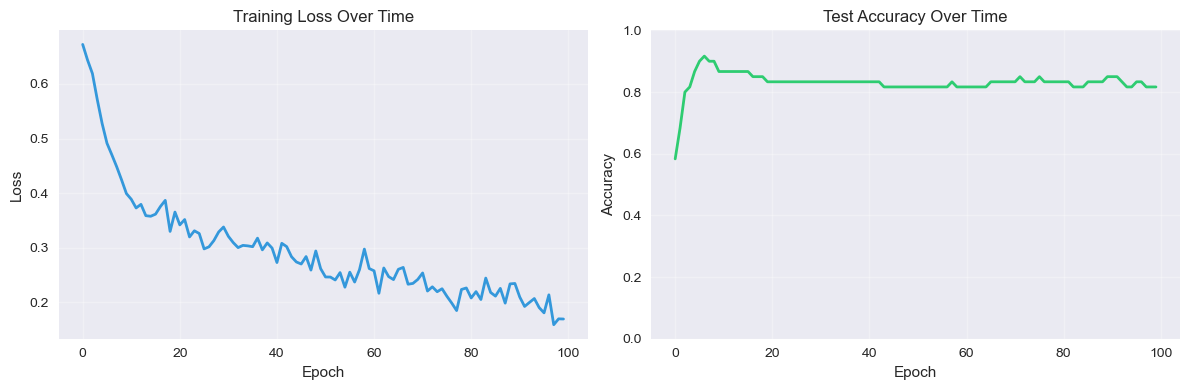

In [68]:
# Visualize training progress
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(train_losses, color='#3498db', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Over Time')
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(test_accuracies, color='#2ecc71', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Test Accuracy Over Time')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 🔍 Interpreting the Training Curves

**Loss curve (left):**
- Should decrease over time as the model learns
- Rapid decrease at first, then stabilizes

**Accuracy curve (right):**
- Should increase over time
- Some fluctuation is normal (especially with small datasets)


---

## ⚠️ Exercise 3: Learning Rate Experiment

**Task:** What happens if you use a much larger learning rate (e.g., 0.1 instead of 0.001)?

Try it and observe the effect on training.

<details>
<summary>💡 <b>Click here for the solution</b></summary>

```python
# Create a fresh model
model_fast = HeartDiseaseNN()

# Train with high learning rate
losses_fast, accs_fast = train_model(
    model_fast, train_loader, X_test_tensor, y_test_tensor,
    epochs=100, learning_rate=0.1  # 100x larger!
)
```

**Expected result:** With a learning rate that's too high:
- The loss may oscillate wildly or even increase
- Accuracy may be unstable or fail to improve
- The model "overshoots" the optimal solution

This is why learning rate is one of the most important hyperparameters to tune!

</details>


---

# Part 6: Model Evaluation

For medical AI, accuracy alone is not enough. We need to understand:
- **Sensitivity/Recall**: What % of sick patients are correctly identified?
- **Specificity**: What % of healthy patients are correctly identified?
- **False negatives**: Sick patients we missed (dangerous!)

---


In [69]:
# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    _, y_pred = torch.max(outputs, 1)

y_pred = y_pred.numpy()
y_proba = probabilities[:, 1].numpy()  # Probability of heart disease

print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Heart Disease']))


📊 Classification Report:
               precision    recall  f1-score   support

      Healthy       0.82      0.84      0.83        32
Heart Disease       0.81      0.79      0.80        28

     accuracy                           0.82        60
    macro avg       0.82      0.81      0.82        60
 weighted avg       0.82      0.82      0.82        60



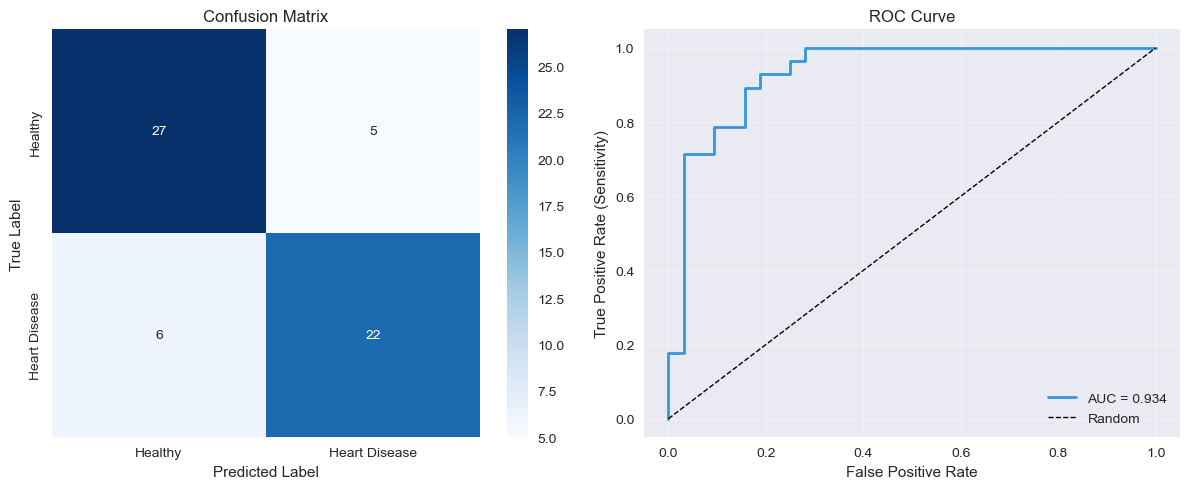


🏥 Clinical Performance Metrics:
   Sensitivity (catching sick patients): 78.6%
   Specificity (identifying healthy): 84.4%
   False negatives (missed cases): 6
   AUC (overall discrimination): 0.934


In [ ]:
# Confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Healthy', 'Heart Disease'],
            yticklabels=['Healthy', 'Heart Disease'])
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#3498db', linewidth=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key metrics
tn, fp, fn, tp = cm.ravel()
print(f"\n🏥 Clinical Performance Metrics:")
print(f"   Sensitivity (catching sick patients): {tp/(tp+fn):.1%}")
print(f"   Specificity (identifying healthy): {tn/(tn+fp):.1%}")
print(f"   False negatives (missed cases): {fn}")
print(f"   AUC (overall discrimination): {roc_auc:.3f}")


### 🏥 Interpreting Clinical Metrics

**Confusion Matrix:**
- **True Positives (TP)**: Correctly predicted heart disease
- **True Negatives (TN)**: Correctly predicted healthy
- **False Positives (FP)**: Healthy labeled as sick (unnecessary tests)
- **False Negatives (FN)**: Sick labeled as healthy ⚠️ **DANGEROUS**

**ROC Curve & AUC:**
- AUC = 0.5 → Random guessing
- AUC = 1.0 → Perfect separation
- AUC > 0.8 → Generally considered good

**For medical screening:**
- We typically want **high sensitivity** (catch all sick patients)
- Even at the cost of some false positives (they get further tests)


---

## ⚠️ Exercise 4: Clinical Decision Making

**Scenario:** You're deploying this model in a screening clinic. The default threshold for classifying a patient as "Heart Disease" is 0.5 probability.

**Question:** Should you lower the threshold to 0.3 or raise it to 0.7? What are the trade-offs?

<details>
<summary>💡 <b>Click here for the answer</b></summary>

### Answer:

**Lowering the threshold to 0.3:**
- ✅ Catches more sick patients (higher sensitivity)
- ❌ More false alarms (lower specificity)
- 👉 **Better for screening** where missing disease is costly

**Raising the threshold to 0.7:**
- ❌ Misses more sick patients (lower sensitivity)
- ✅ Fewer false alarms (higher specificity)
- 👉 **Better for confirmation** when you want high confidence

**For a screening application, we should LOWER the threshold** because:
- Missing heart disease (false negative) can be life-threatening
- A false positive just means additional testing

```python
# Example: Using lower threshold
y_pred_low = (y_proba >= 0.3).astype(int)
print(confusion_matrix(y_test, y_pred_low))
```

</details>


---

# Part 7: Feature Importance

Which clinical factors matter most for the prediction?

We use **permutation importance**: shuffle one feature at a time and see how much accuracy drops.

---


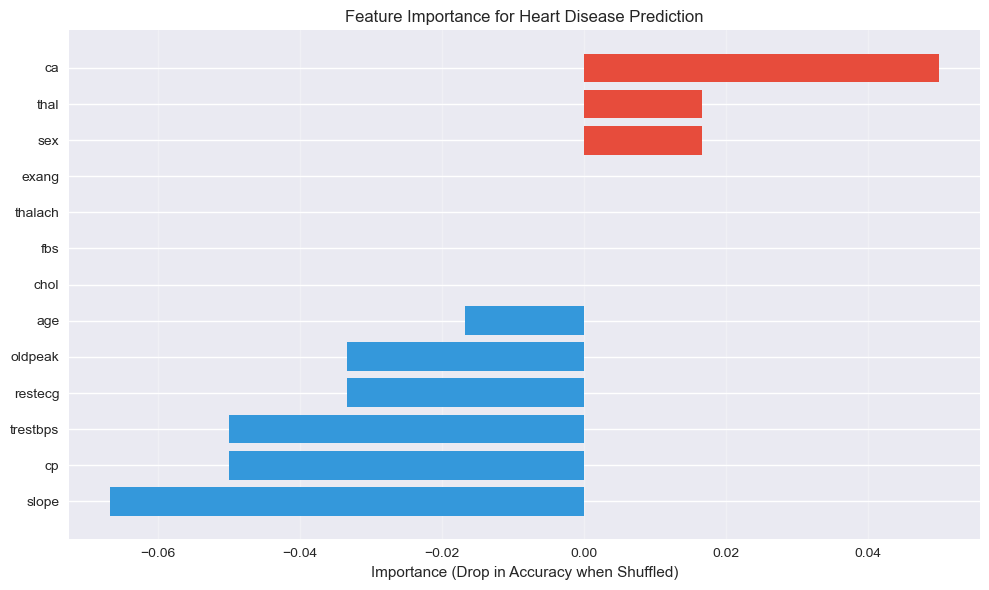


🏆 Top 5 Most Important Features:
   1. ca: 0.050
   2. thal: 0.017
   3. sex: 0.017
   4. exang: 0.000
   5. thalach: 0.000


In [71]:
def calculate_feature_importance(model, X_test, y_test, feature_names):
    """Calculate feature importance using permutation"""
    model.eval()
    
    # Baseline accuracy
    with torch.no_grad():
        _, preds = torch.max(model(X_test), 1)
    baseline_acc = (preds == y_test).float().mean().item()
    
    importances = []
    
    for i in range(X_test.shape[1]):
        # Shuffle feature i
        X_permuted = X_test.clone()
        X_permuted[:, i] = X_permuted[torch.randperm(len(X_test)), i]
        
        # Calculate accuracy with shuffled feature
        with torch.no_grad():
            _, preds = torch.max(model(X_permuted), 1)
        permuted_acc = (preds == y_test).float().mean().item()
        
        # Importance = drop in accuracy
        importances.append(baseline_acc - permuted_acc)
    
    return importances

# Calculate importance
importances = calculate_feature_importance(model, X_test_tensor, y_test_tensor, feature_names)

# Sort and plot
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in [importances[i] for i in sorted_idx]]
plt.barh(range(len(feature_names)), [importances[i] for i in sorted_idx], color=colors)
plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Importance (Drop in Accuracy when Shuffled)')
plt.title('Feature Importance for Heart Disease Prediction')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n🏆 Top 5 Most Important Features:")
for i, idx in enumerate(sorted_idx[:5]):
    print(f"   {i+1}. {feature_names[idx]}: {importances[idx]:.3f}")


### 🔍 Clinical Interpretation

The most important features typically include:

- **ca (major vessels)**: Number of blocked coronary arteries - direct evidence of disease
- **thalach (max heart rate)**: Lower max heart rate indicates reduced cardiac function
- **oldpeak (ST depression)**: ECG abnormality during exercise - sign of ischemia
- **cp (chest pain type)**: Type of symptoms the patient experiences

These align with clinical knowledge about cardiovascular disease!


---

# Summary

## What We Accomplished

1. ✅ **Loaded** real clinical data from UCI Heart Disease dataset
2. ✅ **Explored** the data and identified patterns
3. ✅ **Prepared** data with proper splitting and scaling
4. ✅ **Built** a neural network in PyTorch
5. ✅ **Trained** the model and monitored progress
6. ✅ **Evaluated** using clinically relevant metrics
7. ✅ **Interpreted** which features matter most

## Key Takeaways

- **Data quality matters**: Proper preprocessing is crucial
- **Evaluation goes beyond accuracy**: Sensitivity and specificity matter in medicine
- **Models are interpretable**: We can understand what the model learned
- **Clinical context is essential**: Technical metrics must be interpreted clinically

## Limitations & Next Steps

- ⚠️ Small dataset (297 patients) - larger data would improve reliability
- ⚠️ Single center data - may not generalize to other populations
- 📈 Could try more complex architectures or ensemble methods
- 🏥 Would need clinical validation before real-world deployment


---

## ⚠️ Final Exercise: Reflection Questions

Consider these questions for discussion:

1. **Is ~85% accuracy good enough for clinical use?** What factors would you consider?

2. **What could go wrong** if we deployed this model without further validation?

3. **How would you explain** the model's predictions to a patient?

<details>
<summary>💡 <b>Click here for discussion points</b></summary>

### 1. Is ~85% accuracy good enough?

**Depends on the use case:**
- For **screening** (initial filter): Might be acceptable with high sensitivity
- For **diagnosis** (definitive): Probably not - would want 95%+ with clinical validation
- For **triage** (prioritization): Could be useful to flag high-risk patients

**Consider:**
- What happens with false negatives? (missed disease = potential harm)
- What happens with false positives? (unnecessary tests = cost and anxiety)

### 2. What could go wrong?

- **Dataset shift**: Different patient population than training data
- **Missing values**: Real data often has missing features
- **Overconfidence**: Model may be wrong but confident
- **Bias**: May perform worse for underrepresented groups

### 3. Explaining to patients

- Use feature importance to explain key factors
- Frame as "decision support" not "diagnosis"
- Emphasize that final decision is with the physician
- Discuss uncertainty and need for further tests

</details>


---

### Next: B4 - ECG Arrhythmia Classification with CNNs

In the next notebook, we'll work with **time-series ECG data** and use **Convolutional Neural Networks (CNNs)** for arrhythmia detection.

---
